# The Rubik's Cube Scrambling Markov Chain

Fix $n \in \lbrace 2, 3 \rbrace.$ Recall the $\textbf{$n$-dimensional Rubik's Cube}$ is a cube such that each of its $6$ square faces is partitioned into $n^2$ smaller colored squares, known as $\textbf{stickers}.$ Each sticker takes on one color from a set of $6$ distinct colors. We refer to any state of the cube with $6n^2$ colored stickers as a $\textbf{(colored) cube configuration}.$ 

Below are examples of 2D and 3D cube configurations, respectively.
<table><tr>
    
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%201.gif" alt="Drawing" style="width: 50px;"/> <figcaption> An Arbitrary 2D Rubik's Cube Configuration </figcaption> 
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%201.gif" alt="Drawing" style="width: 50px;"/> <figcaption> An Arbitrary 3D Rubik's Cube Configuration </figcaption>  </td>
</tr></table>

We refer to a $\textbf{solved configuration}$ as a configuration such that each square face has its $n^2$ stickers that are of the same color.

Below are examples of 2D and 3D solved cube configurations, respectively.
<table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%202.gif" alt="Drawing" style="width: 50px;"/> <figcaption> A Solved 2D Rubik's Cube Configuration </figcaption> 
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%202.gif" alt="Drawing" style="width: 50px;"/> <figcaption> A Solved 3D Rubik's Cube Configuration </figcaption> </td>
</tr></table>

We can transition between any two cube configurations by performing a sequence of face rotations in succession. A $\textbf{face rotation (scramble)}$ is either a $90$ or $180$ clockwise or counterclockwise rotation of a selected face.

Fix the dimension $n \in \lbrace 2,3 \rbrace$ of the Rubik's Cube. Define $\mathcal{G}_n$ to be the set of all possible cube configurations. Given an arbitrary cube configuration $c \in \mathcal{G}_n,$ the standard puzzle is to $\textbf{solve (unscramble)}$ it, which means to find a sequence of face rotations needed to obtain a solved configuration. 

For each $c \in \mathcal{G}_n,$ let $m_c$ be the $\textit{minimal}$ number of face rotations needed to obtain a solved configuration from $c.$ Define $\textbf{God's number}$ to be the number $$M_n=\max_{c \in \mathcal{G}_n} m_c.$$ In words, $M_n$ is the maximum number of moves needed to efficiently unscramble the cube. We pose the following question:

* What is the value of $M_n$ ?


Next, begin with a solved configuration of the cube. Let $t$ be a fixed number of face rotations made. We pose the following questions:
* Given any configuration $c \in \mathcal{G}_n,$ what is the probability of obtaining $c$ in exactly $t$ scrambles ? 
* As $t$ gets large, is it possible to obtain most, if not all, configurations in $\mathcal{G}_n$ with equal probability ? 

In this notebook, we answer all the questions we posed. We specifically invoke tools from basic Group Theory and Markov Chain theory.

In [1]:
from CubeConfiguration import *
from MarkovGraph import *
from MarkovChainCalculations import *
import matplotlib.pyplot as plt

# Orienting the Rubiks Cube

Fix a dimension $n \in \lbrace 2,3 \rbrace.$ We first discuss how to orient the faces of the $n$-dimensional Rubik's cube. 

The diagrams below identifies the front (F), left (L), up (U), back (B), right (R), down (D) faces of a generic 3D cube configuration (one can imagine how the diagram for a generic 2D configuration would look).

<!-- <table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%20znaceni%20tahu%201.png" alt="Drawing" with="100px"/> <figcaption>Configuration with Identified Faces and their Clockwise Orientations From a Certiain Vantage Point </figcaption> </td>
</tr></table>
 -->

<table><tr>
<td> <img src="https://images.saymedia-content.com/.image/c_limit%2Ccs_srgb%2Cq_auto:eco%2Cw_1200/MTc0MjYyNzAyNzY2NTY1MjQ0/rubik-cube-algorithms.webp" alt="Drawing" width="500px"/> <figcaption> Configuration with Identified Faces and Orientations </figcaption> </td>
</tr></table>


Now, choose a particular face of the cube. View the face as though it were in front of the screen such that:

* For F: The red arrow in the above corresponding diagram is on the top of the face and is pointing right.
* For L: The red arrow in the above corresponding diagram is on the right of the face and is pointing down.
* For U: The red arrow in the above corresponding diagram is on the bottom of the face and is pointing left.
* For B: The red arrow in the above corresponding diagram is on the top of the face and is pointing right.
* For R: The red arrow in the above corresponding diagram is on the left of the face and is pointing up.
* For D: The red arrow in the above corresponding diagram is on top of the face and is pointing right.


A $\textbf{face rotation (scramble)}$ is a $90$ or $180$ degree clockwise/counterclockwise rotation of a cube's face, where the clockwise/counterclockwise directions are relative to the face's specified orientation as described above.

# Cube Sticker Enumeration Scheme 

Fix any solved configuration of the cube. Position the cube as in the above diagram, and identify the locations of the F, L, U, B, R, and D faces. Now, enumerate all its $6n^2$ stickers from the set $\lbrace 0, \ \dots \ , 6n^2-1 \rbrace$ in the following order of faces: F, L, U, B, R, and D, in which we view each face according to the aforementioned orientation procedure. In particular, enumerate the stickers of each face in row-wise fashion.

For example, in the case $n=2,$ if we choose a solved configuration and identify each face of our chosen configuration as a $2 \times 2$ matrix with stickers as its entries, the enumeration procedure above will yield: 
$$F= \begin{bmatrix} 0 & 1 \\ 2 & 3 \end{bmatrix},  \ L= \begin{bmatrix} 4 & 5 \\ 6 & 7 \end{bmatrix},  \ U= \begin{bmatrix} 8 & 9 \\ 10 & 11 \end{bmatrix}, \ B = \begin{bmatrix} 12 & 13 \\ 14 & 15 \end{bmatrix}, \ R = \begin{bmatrix} 16 & 17 \\ 18 & 19 \end{bmatrix}, \ D= \begin{bmatrix} 20 & 21 \\ 22 & 23 \end{bmatrix}.$$


In the code cell below, we output enumerated configurations as dictionaries. Each dictionary has keys that are the $6$ face names and values that are the $6$ corresponding $n \times n$ face matrices. We first show the solved configuration dictionary. Then, we show the configuration dictionary obtained from rotating a certain face clockwise. 

In [2]:
n=2
solved_cube_configuration_dict=CubeConfiguration(n).configuration_dict
print("Original {}D Solved Cube Configuration:".format(n))
for key in solved_cube_configuration_dict.keys():
    print( "{} : {}".format(key, solved_cube_configuration_dict[key]))
print(" ")

face_name='Front'
solved_cube_configuration_rotated_dict=CubeConfiguration(n).rotate_face(face_name)
print("Configuration After Rotating the Solved Configuration's {} Face Clockwise Once:".format(face_name))
for key in solved_cube_configuration_rotated_dict.keys():
    print( "{} : {}".format(key, solved_cube_configuration_rotated_dict[key]))

Original 2D Solved Cube Configuration:
Front : [[0 1]
 [2 3]]
Left : [[4 5]
 [6 7]]
Up : [[ 8  9]
 [10 11]]
Back : [[12 13]
 [14 15]]
Right : [[16 17]
 [18 19]]
Down : [[20 21]
 [22 23]]
 
Configuration After Rotating the Solved Configuration's Front Face Clockwise Once:
Front : [[2 0]
 [3 1]]
Left : [[ 4 20]
 [ 6 21]]
Up : [[8 9]
 [7 5]]
Back : [[12 13]
 [14 15]]
Right : [[10 17]
 [11 19]]
Down : [[18 16]
 [22 23]]


# Permutations 

For each $m \in \mathbb{N},$ let $S_m$ is the set of all bijections from the set $\lbrace 0, \ \dots \ , m-1 \rbrace$ to itself. Recall this is a group under function composition. Elements of $S_m$ are known as $\textbf{permutations}.$

We say a permutation $\tau \in S_m$ is a $\textbf{cyclic permutation}$ if there exist distinct $i_1, \ \dots \ , i_k \in \lbrace 0, \ \dots \ , m-1 \rbrace$  such that $\tau(i_j)=\tau_{i_{j+1}}$ for all $1 \le j \le k-1$ and $\tau(i_k)=i_1.$ In this case, we adopt the conventional $\textbf{cyclic notation},$ in which we write $$\tau=(i_1 \ \dots \  i_k).$$ 

Let $\tau=(i_1 \ \dots \  i_k)$ and $\kappa=(j_1 \ \dots \  j_m)$ be cyclic permutations in $S_m.$ We say $\tau$ and $\kappa$ are $\textbf{disjoint}$ if the numbers $i_1, \ \dots \ , i_k,  j_1, \ \dots \ , j_m$ are all distinct. It is a well-known theorem that every $\sigma \in S_m$ can be written as a composition of pairwise disjoint cyclic permutations in $S_m.$

If $\sigma \in S_m$ and $p \in \mathbb{N},$ we also define the $\textbf{$p$-th power}$ of $\sigma$ to be the permutation $$\sigma^p=\underbrace{\sigma \circ \ \dots \ \circ \sigma}_{p \text{ times}}.$$

# Identifying Cube Configurations with Permutations

We identify our chosen solved configuration from above with the identity permutation $\textbf{Id} \in S_{6n^2}.$ In this setting, a face rotation is a certain permutation of the $6n^2$ enumerated stickers. We define the permutations $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \in S_{6n^2},$ which identify the individual configurations resulting from rotating each of the solved configuration's individual F, L, U, B, R, and D faces once clockwise. 

$\textbf{Theorem}:$ For each $\mathbf{M} \in \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rbrace,$ its inverse is $\mathbf{M}^3,$ which corresponds to the configuration resulting from rotating our solved configuration's M face once counterclockwise.

Consequently, we define the set $$\mathcal{B}_n= \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D},\mathbf{F}^2, \mathbf{L}^2, \mathbf{U}^2, \mathbf{B}^2, \mathbf{R}^2, \mathbf{D}^2, \mathbf{F}^3, \mathbf{L}^3, \mathbf{U}^3, \mathbf{B}^3, \mathbf{R}^3, \mathbf{D}^3 \rbrace$$ to be the set of all $\textbf{basic face rotation permutations}$ for the $n$-dimensional Rubik's Cube.

In the code cell below, we output the corresponding basic face rotation permutations for the $n$-dimensional Rubik's Cube.


$\textbf{Note}:$ When $n=2,$ one can actually confirm by inspection that for any fixed 2D cube configuration, rotating the front face once clockwise/counterclockwise yields the same effect as rotating the back face once counterclockwise/clockwise; the resulting configurations from each case are actually the same up to vantage point. Hence, we can identify $\mathbf{F}$ with $\mathbf{B}^3$ and $\mathbf{B}$ with $\mathbf{F}^3.$  Similarly, we can identify $\mathbf{L}$ with $\mathbf{R}^3$ and $\mathbf{R}$ with $\mathbf{L}^3$ and $\mathbf{U}$ with $\mathbf{D}^3$ and $\mathbf{D}$ with $\mathbf{U}^3.$ Consequently, we can identify $\mathbf{B}^2$ with $\mathbf{F}^2$ and $\mathbf{R}^2$ with $\mathbf{L}^2$ and $\mathbf{D}^2$ with $\mathbf{U}^2.$ So there are $9$ distinct basic face rotation permutations for the case $n=2.$

However, when $n=3,$ one can actualy confirm by inspection on any 3D cube configuration that the above identifications cannot be made. Hence, there are $18$ distinct basic face rotation permutations for the case $n=3.$

In [3]:
n=2
if n==2:
    face_rotation_moves= ['F','L','U','FF','LL','UU','FFF','LLL','UUU']
else:
    face_rotation_moves= ['F','L','U','B','R','D','FF','LL','UU','BB','RR','DD',
                          'FFF','LLL','UUU','BBB','RRR','DDD']
face_rotation_permutations = get_face_rotation_permutations(n)
print(dict(zip(face_rotation_moves, face_rotation_permutations)))

{'F': Permutation(23)(0, 2, 3, 1)(5, 20, 18, 11)(7, 21, 16, 10), 'L': Permutation(23)(0, 8, 15, 20)(2, 10, 13, 22)(4, 6, 7, 5), 'U': Permutation(23)(0, 16, 12, 4)(1, 17, 13, 5)(8, 10, 11, 9), 'FF': Permutation(23)(0, 3)(1, 2)(5, 18)(7, 16)(10, 21)(11, 20), 'LL': Permutation(23)(0, 15)(2, 13)(4, 7)(5, 6)(8, 20)(10, 22), 'UU': Permutation(23)(0, 12)(1, 13)(4, 16)(5, 17)(8, 11)(9, 10), 'FFF': Permutation(23)(0, 1, 3, 2)(5, 11, 18, 20)(7, 10, 16, 21), 'LLL': Permutation(23)(0, 20, 15, 8)(2, 22, 13, 10)(4, 5, 7, 6), 'UUU': Permutation(23)(0, 4, 12, 16)(1, 5, 13, 17)(8, 9, 11, 10)}


# Determining God's Number via A Devil's Algorithm. 

We are ready to answer the first question we posed, which is to determine God's number $M_n$ for the $n$-dimensional Rubiks Cube. Recall God's number is the maximum number of moves needed to efficiently unscramble the cube. 

In order to do this, we iteratively construct the set
$$\mathcal{H}_n= \langle \mathcal{B}_n \rangle$$ in $S_{6n^2},$ which is the subgroup generated by all the face rotation permutations, where $\mathcal{B}_n$ is the set of aforementioned basic face rotation permutations. Explicitly,
$$\mathcal{H}_n = \left \lbrace \mathbf{M}_1 \circ \ \dots \ \circ \mathbf{M}_k: k \in \mathbb{N}, \  \mathbf{M}_i \in \mathcal{B}_n \right \rbrace.$$

$\textbf{Theorem}:$ There is a bijective correspondence between $\mathcal{G}_n$ and $\mathcal{H}_n.$ In other words, each cube configuration can be uniquely identified with a composition of face rotation permutations.  

We iteratively construct the entire subgroup $\mathcal{H}_n$ following a Devil's Algorithm. We do this as follows.
* Define $\mathcal{H}_{1,n} = \lbrace \mathbf{Id} \rbrace.$ 
* For each $k>1,$ we define $$\mathcal{H}_{k,n} = \mathcal{H}_{k-1,n} \cup  \left \lbrace \mathbf{M} \circ \sigma: \ \sigma \in \mathcal{H}_{k-1,n}, \  \mathbf{M} \in \mathcal{B}_n \right \rbrace.$$
* We terminate the algorithm once we find a $k \in \mathbb{N}$ such that $\mathcal{H}_{k,n}=\mathcal{H}_{k-1,n}.$

$\textbf{Theorem}:$ The Devil's Algorithm terminates for some $k \in \mathbb{N}.$ For such a $k,$ we have $\mathcal{H}_{k,n}=\mathcal{H}_n.$ Furthermore, the smallest such $k$ is equal to $M_n.$
 
With sheer computing power, we verified $M_2=11$ and $\# \ \mathcal{H}_2=3674160.$ Google proved that $M_3 = 20$ and $\# \ \mathcal{H}_3=43252003274489856000,$ but we do not have enough computing power to verify this. We implement this algorithm in the code cell below.

In [4]:
# !rm -r "2D Scrambling Chain"
# MG=MarkovGraph(n)
# max_iterations = 11
# for k in range(max_iterations):
#     print("ITERATION {}".format(k))
#     MG.update_chain()
#     print(" ")
# MG.transition_matrix

# Markov Chain

Let $\lbrace S_t \rbrace_{t \ge 0}$ be a collection of random variables defined on a common state space $\mathcal{S}.$ Recall $\lbrace S_t \rbrace_{t \ge 0}$ is a $\textbf{Markov Chain}$ if for all $t \ge 0,$ and all $s_0, \ \dots \ , s_{t+1} \in \mathcal{S},$ we have that 

$$\text{Pr}\left(S_{t+1} = s_{t+1} \ | \ S_{t} = s_t \right) = \text{Pr}\left(S_{t+1} = s_{t+1} \ | \ S_{t} = s_t \cap  S_{t-1}=s_{t-1} \cap \ \dots \ \cap S_0=s_0  \right),$$ where $\text{Pr}(B \ | \ A)$ denotes the conditional probability of event $B$ given event $A$ occurred. In words, the probability of transitioning to a future state depends only on the current state. 

# Constructing the Scrambling Markov Chain

Let $N= \#  \ \mathcal{H}_n,$ where $\mathcal{H}_n$ is the subgroup generated by the basic face rotation permutations as we defined above. Enumerate $\mathcal{H}_n=\lbrace h_0, \ \dots \ , h_{N-1} \rbrace$ with $h_0=\textbf{Id}.$

Define $H_0$ to be the constant random variable $\textbf{Id}$ and $H_t$ to be the random variable representing the permutation obtained from composing $t$ basic face rotation permutations for each $t \in \mathbb{N}.$ Each random variable is defined on the common state space $\mathcal{H}_n.$ We call the collection of random variables $\lbrace H_t \rbrace_{t \ge 0}$ the $\textbf{scrambling chain}.$

$\textbf{Theorem}:$ The Scrambling Chain is a Markov Chain.

Associated with this Markov Chain is an $N \times N$ transition matrix $P,$ whose $(i,j)$-th entry is 
$$P_{i,j}=\text{Pr}\left(H_{t+1}= h_j \ | \ H_{t}=h_i \right)$$ for all $i,j \in \lbrace 0, \ \dots  \ , N-1 \rbrace.$ Note that the entries of $P$ are actually defined independent of the value of $t.$

$\textbf{Theorem}:$  The transition matrix $P$ is a symmetric matrix i.e. $P_{i,j}=P_{j,i}.$ In the case $n=2,$ each row of $P$ has exactly $9$ nonzero entries which are equal to $1/9.$ In the case $n=3,$ each row of $P$ has exactly $18$ nonzero entries which are equal to $1/18.$ 

In the code cell below, we load the corresponding $N \times N$ transition matrix $P$ in $\textbf{coordinate list (COO) format},$ which is a special type of data representation encoding the positions of the nonzero matrix entries as index triplets (see https://scipy-lectures.org/advanced/scipy_sparse/coo_matrix.html). This format makes it very suitable for sparse matrix-vector calculations.  

In [5]:
MC = MarkovChainCalculations(n)
transition_matrix = MC.transition_matrix
transition_matrix

LOADING TRANSITION MATRIX IN SPARSE COO FORMAT ... 
DONE !!!


<3674160x3674160 sparse matrix of type '<class 'numpy.float64'>'
	with 33067440 stored elements in COOrdinate format>

# Computing Scrambling Chain Distributions

For each $t \ge 0,$ we define $\pi_t$ to be the probability distribution corresponding to the random variable $H_t$ from the scrambling chain. Explicitly, for each $h \in \mathcal{H}_n,$ we have $$\pi_t(h)=\text{Pr} (H_t=h).$$

$\textbf{Theorem}:$ For each $t \ge 0$ and each $i \in \lbrace 0, \ \dots \ , N-1 \rbrace,$ we have 

\begin{align*}
    \pi_{t+1}(h_i) &= \sum_{j=0}^{N-1} P_{i,j} \pi_{t}(h_j).
\end{align*}

As a matter of fact, we can recursively compute $\pi_t$ using sparse matrix-vector multiplication. For each $t \ge 0,$ denote
$$\boldsymbol{\pi}_t=(\pi_t(h_0), \ \dots \ , \pi_t(h_{N-1})) \in \mathbb{R}^N.$$ Our above theorem is equivalent to the statement
$$\boldsymbol{\pi}_{t+1} = P \boldsymbol{\pi}_t$$ for each $t \ge 0.$ 

We implement this formula in the code cell below and plot the first few chain distributions for the scrambling chain. 

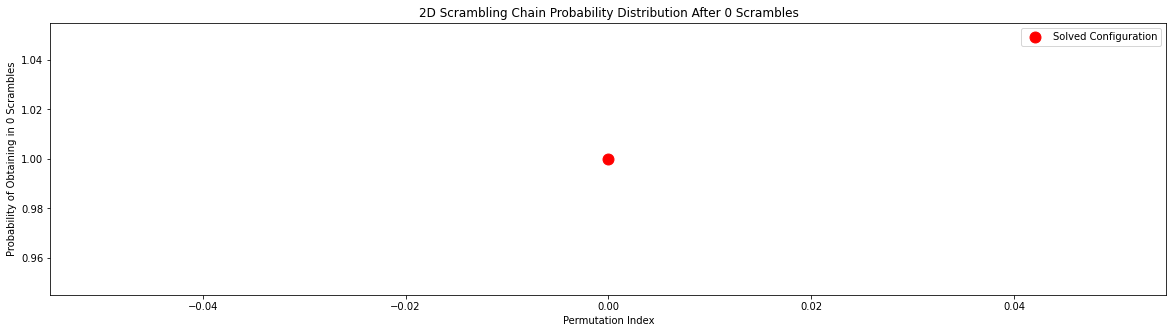

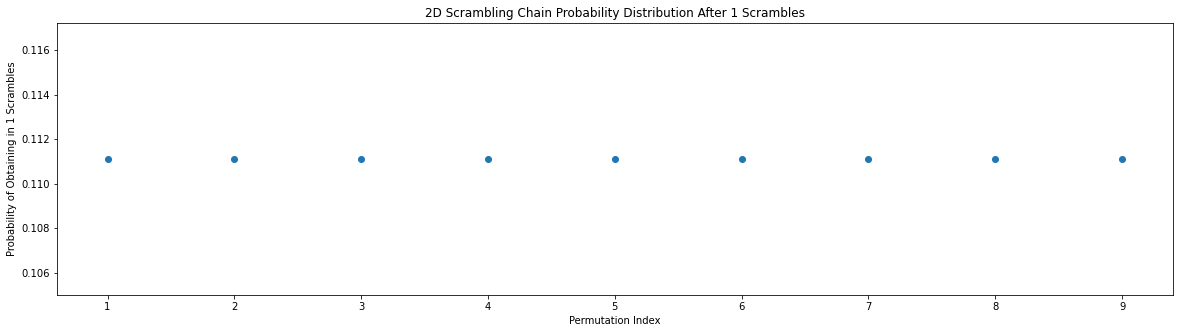

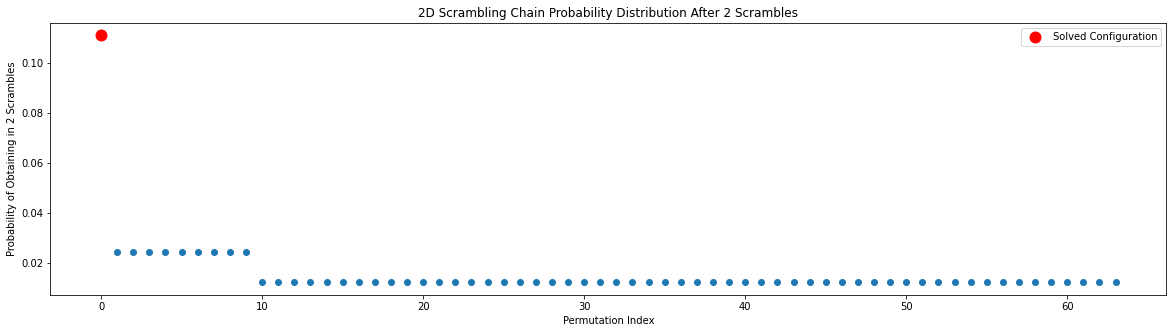

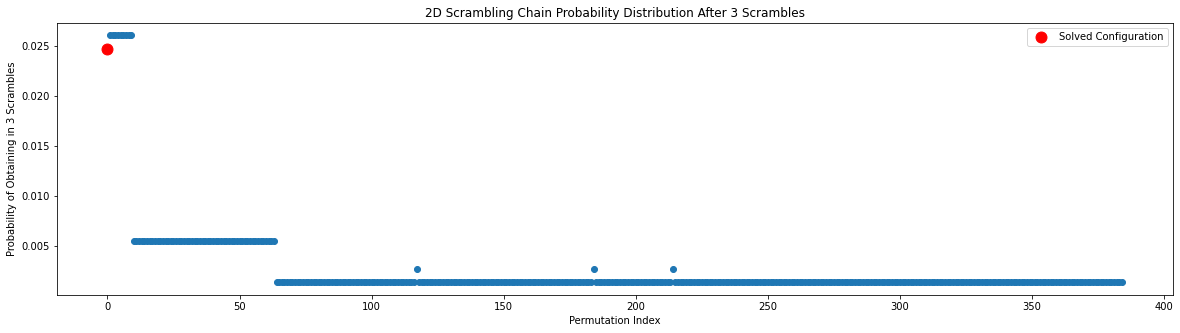

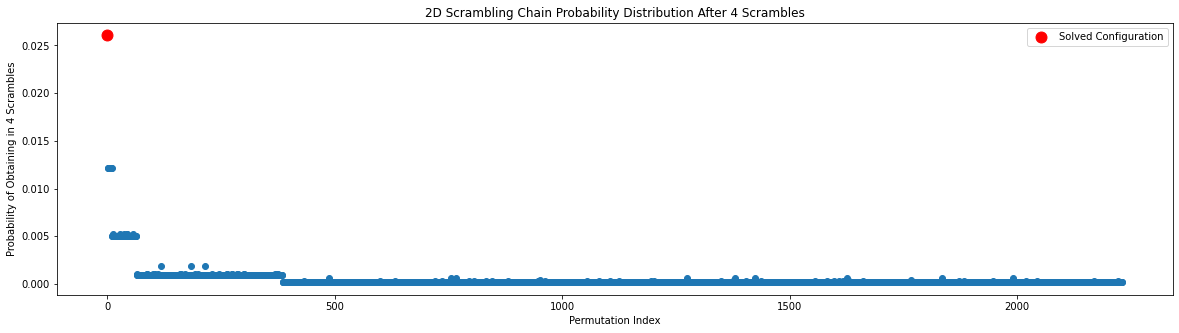

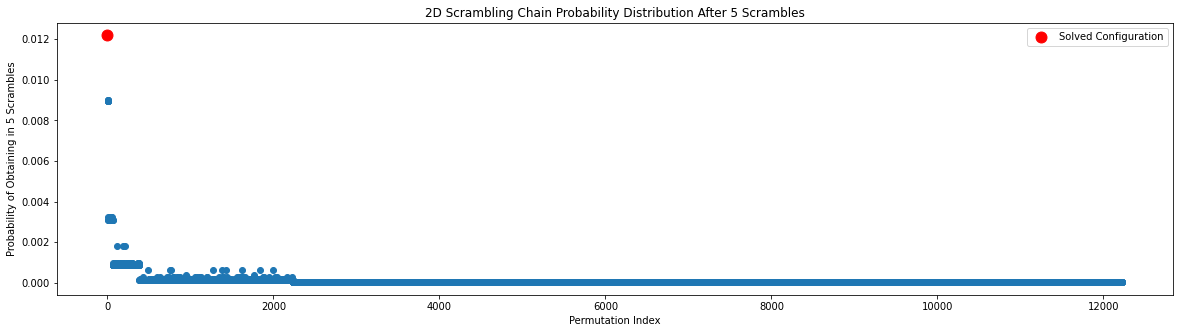

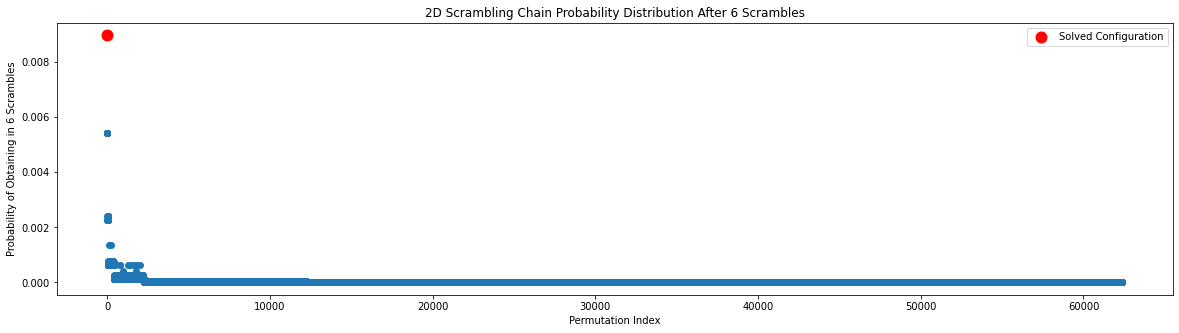

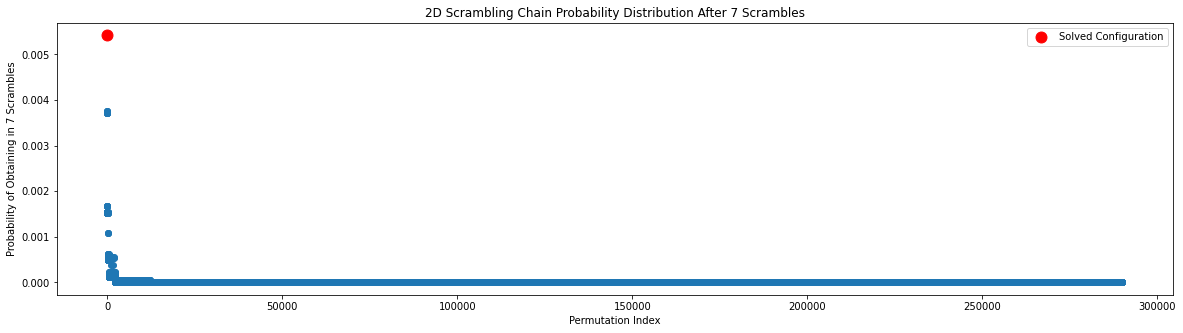

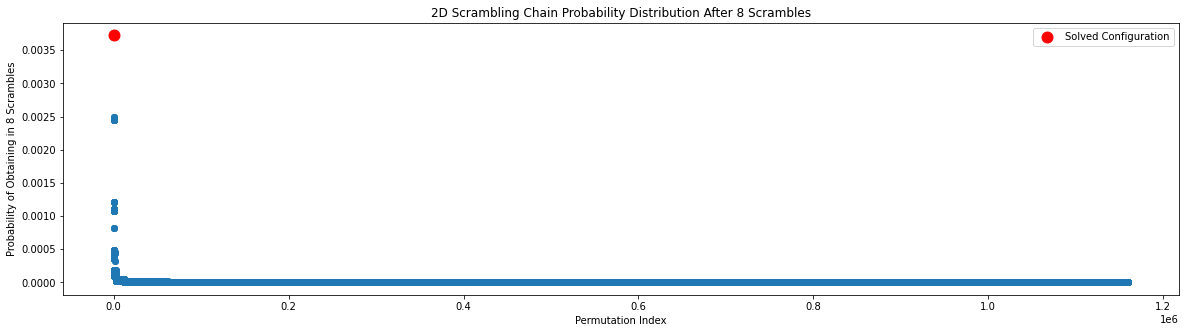

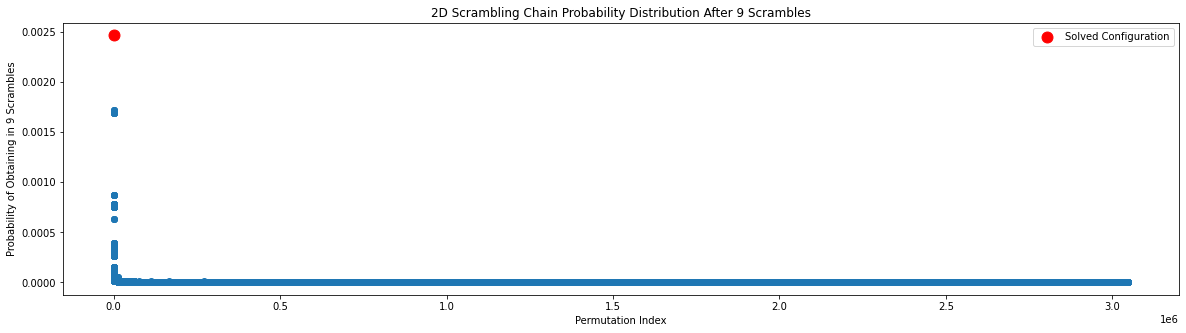

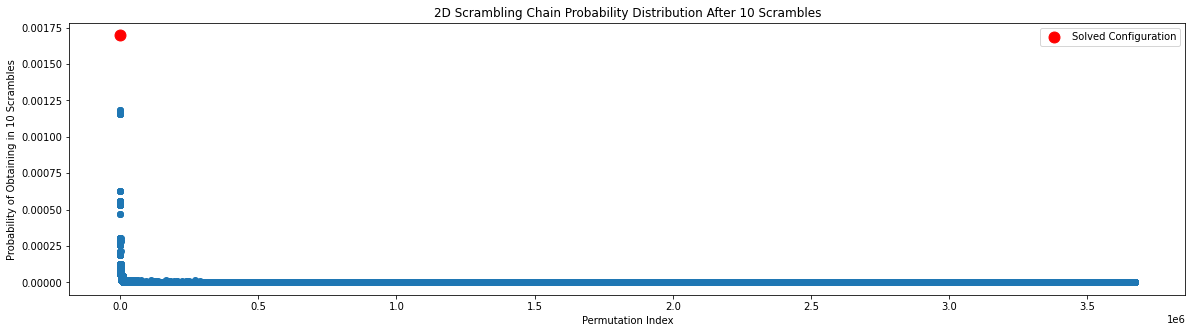

In [6]:
max_scrambles=30
for t in range(max_scrambles):
    pi_t = MC.compute_chain_distribution(t)
    if t<=10:
        fig,ax=plt.subplots(figsize=(20,5))
        permutation_indices=pi_t.nonzero()[0]
        ax.scatter(permutation_indices, pi_t.data)
        if 0 in permutation_indices:
            ax.scatter([0], pi_t.data[0],color='red',label='Solved Configuration',s=120)
            ax.legend()
        ax.set_title('{}D Scrambling Chain Probability Distribution After {} Scrambles'.format(n,t))
        ax.set_xlabel('Permutation Index')
        ax.set_ylabel('Probability of Obtaining in {} Scrambles'.format(t))

$\textbf{Conjecture}:$ If $t>3,$ it seems that $\pi_t \left(\textbf{Id} \right) > \pi_t(h)$ for all $h \ne \textbf{Id}.$ In words, after three scrambles, it seems we are most likely to recover the solved configuration we started with ! Hence, we speculate that we cannot obtain all cube configurations with equal probability. So scrambling the cube may be theoretically impossible ! 

But let's look at another type of computation.

# Obtaining Scrambling Chain Total Variation Distances To Discrete Uniform
Consider the discrete uniform distribution $\pi_\infty$ on $\mathcal{H}_n,$ that is, $\pi_\infty(h)=1/N$ for each $h \in \mathcal{H}_n,$ where $N = \# \ \mathcal{H}_n$ as before. 

For each $t \in \mathbb{N},$ we compute the $\textbf{total variation distance}$ between $\pi_t$ and $\pi_\infty,$ which is the quantity
$$\text{TV}(\pi_t,\pi_\infty) = \frac{\|\boldsymbol{\pi}_t - \boldsymbol{\pi}_\infty \|_1}{2} ,$$ where $\boldsymbol{\pi}_\infty=(1/N, \ \dots \ , 1/N) \in \mathbb{R}^N$ and is the $\ell^1$-norm of the vector
$$\| \mathbf{x} \|_1= \sum_{i=0}^{N-1} |x_i|$$ with $\mathbf{x}=(x_0, \ \dots \ , x_{N-1}) \in \mathbb{R}^N.$

In the code cell below, we compute and plot the first few total variation distances for the scrambling chain.

<AxesSubplot:title={'center':'2D Scrambling Chain Total Variation Distance to Discrete Uniform'}, xlabel='Chain Distribution Index', ylabel='Total Variation Distance to Discrete Uniform Distribution'>

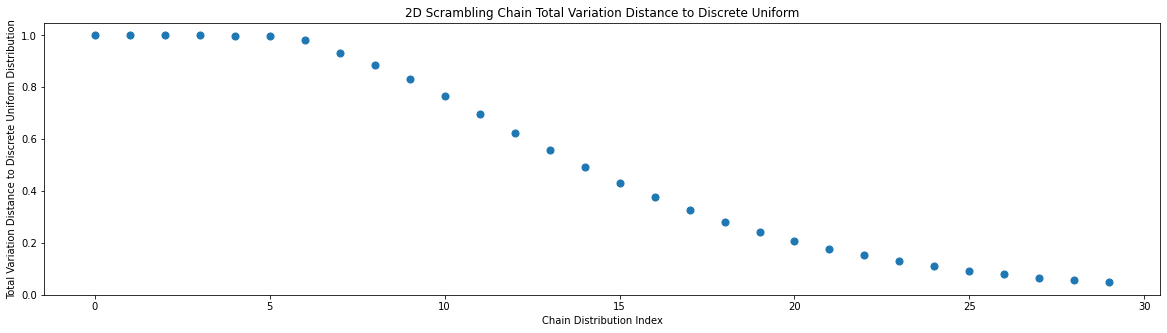

In [8]:
current_total_variation_distances_df=MC.compute_current_total_variation_distances_df()
current_total_variation_distances_df.reset_index(inplace=True)
current_total_variation_distances_df.plot.scatter(x=current_total_variation_distances_df.columns[0],
                                                  y=current_total_variation_distances_df.columns[1],
                                                  figsize=(20,5),
                                                  title='{}D Scrambling Chain Total Variation Distance to Discrete Uniform'.format(n),
                                                  s=50)

$\textbf{Conjecture}:$ It seems that $$\lim_{t \rightarrow \infty} \text{TV}(\pi_t,\pi_\infty) = 0.$$ So the scrambling chain distributions do seem to be approaching the discrete uniform distribution with respect to the total variation distance. In Markov Chain terms, the discrete uniform distribution does seem to be the correct stationary distribution of the scrambling chain. This suggests that in the long run, we will come close to scrambling the cube, but we will never actually accomplish it. 

# References

* Pocket Cube Devil's Algorithm: http://anttila.ca/michael/devilsalgorithm/.
* Pocket Cube Markov Chain Mixing Time Results: https://www.lifehacker.com.au/2020/01/how-hard-is-it-to-scramble-rubiks-cube/
* 3D Rubiks Cube Simulator with Sticker Labels: https://iamthecu.be/
* 2D Pocket Cube Simulator: https://www.grubiks.com/puzzles/rubiks-mini-cube-2x2x2/